/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2551/908824020.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit




DEUTSCH-JOZSA ALGORITHM - GENERALIZED IMPLEMENTATION

The program automatically tests constant and balanced functions for n = 2, 3, 4 and 5 input qubits.


NUMBER OF INPUT QUBITS : 2

CONSTANT FUNCTION
--------------------------------------------------------------------------------

QUANTUM CIRCUIT
--------------------------------------------------------------------------------
     ┌───┐     ┌───────────┐┌───┐
q_0: ┤ H ├─────┤0          ├┤ H ├
     ├───┤     │           │├───┤
q_1: ┤ H ├─────┤1 Constant ├┤ H ├
     ├───┤┌───┐│           │└───┘
q_2: ┤ X ├┤ H ├┤2          ├─────
     └───┘└───┘└───────────┘     

MEASUREMENT RESULTS
--------------------------------------------------------------------------------
Input qubits          : 2
Shots                 : 1000
Most probable output  : 00
All-zero count        : 1000
Non-zero count        : 0
Classification        : CONSTANT

BALANCED FUNCTION
--------------------------------------------------------------------------------

QUANTU

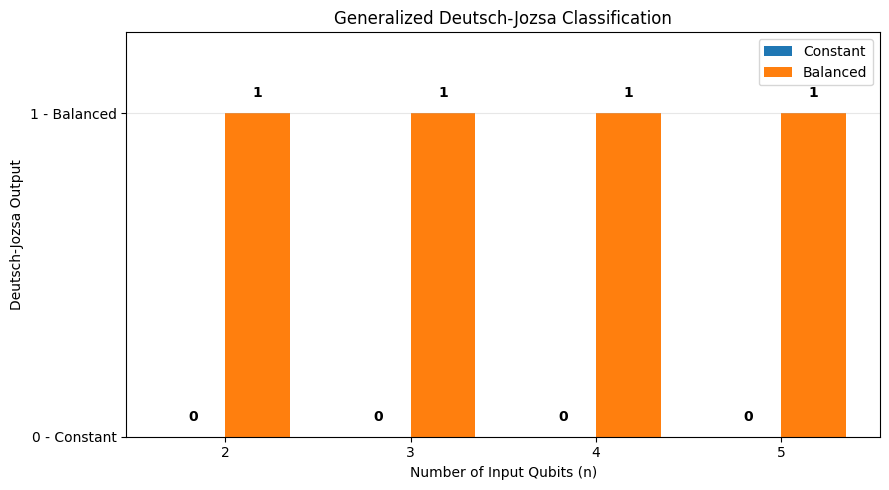

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1000
SEED = 42


# ---------------------------------------------------------
# CREATE CONSTANT ORACLE
# ---------------------------------------------------------

def create_constant_oracle(n):
    """
    Constant function:
    f(x) = 0 for every input x
    """

    oracle = QuantumCircuit(
        n + 1,
        name="Constant"
    )

    # No operation is needed for f(x) = 0

    return oracle.to_gate()


# ---------------------------------------------------------
# CREATE BALANCED ORACLE
# ---------------------------------------------------------

def create_balanced_oracle(n):
    """
    Balanced parity function:

    f(x0, x1, ..., xn-1)
    = x0 XOR x1 XOR ... XOR xn-1
    """

    oracle = QuantumCircuit(
        n + 1,
        name="Parity"
    )

    for qubit in range(n):
        oracle.cx(
            qubit,
            n
        )

    return oracle.to_gate()


# ---------------------------------------------------------
# BUILD DEUTSCH-JOZSA CIRCUIT
# ---------------------------------------------------------

def build_deutsch_jozsa(n, function_type):

    qc = QuantumCircuit(
        n + 1
    )

    # -----------------------------------------------------
    # INITIAL SUPERPOSITION
    # -----------------------------------------------------

    for qubit in range(n):
        qc.h(qubit)

    # -----------------------------------------------------
    # PREPARE ANCILLA IN |1>
    # -----------------------------------------------------

    qc.x(n)

    # Convert |1> to |->

    qc.h(n)

    # -----------------------------------------------------
    # SELECT ORACLE AUTOMATICALLY
    # -----------------------------------------------------

    if function_type == "constant":

        oracle = create_constant_oracle(n)

    elif function_type == "balanced":

        oracle = create_balanced_oracle(n)

    else:

        raise ValueError(
            "Invalid function type"
        )

    # -----------------------------------------------------
    # ONE ORACLE QUERY
    # -----------------------------------------------------

    qc.append(
        oracle,
        list(range(n + 1))
    )

    # -----------------------------------------------------
    # FINAL HADAMARD ON INPUT REGISTER
    # -----------------------------------------------------

    for qubit in range(n):
        qc.h(qubit)

    return qc


# ---------------------------------------------------------
# GET INPUT REGISTER PROBABILITIES
# ---------------------------------------------------------

def get_input_probabilities(
    statevector,
    n
):

    full_probabilities = (
        statevector.probabilities()
    )

    input_probabilities = np.zeros(
        2 ** n
    )

    # The last qubit is the ancilla.
    # Combine probabilities for both ancilla states.

    for index, probability in enumerate(
        full_probabilities
    ):

        input_value = index % (2 ** n)

        input_probabilities[
            input_value
        ] += probability

    # Normalize to avoid floating-point
    # precision problems.

    input_probabilities = (
        input_probabilities
        / np.sum(input_probabilities)
    )

    return input_probabilities


# ---------------------------------------------------------
# SIMULATE MEASUREMENTS
# ---------------------------------------------------------

def simulate_measurements(
    probabilities,
    shots=SHOTS,
    seed=SEED
):

    rng = np.random.default_rng(
        seed
    )

    outcomes = np.arange(
        len(probabilities)
    )

    samples = rng.choice(
        outcomes,
        size=shots,
        p=probabilities
    )

    counts = np.bincount(
        samples,
        minlength=len(probabilities)
    )

    return counts


# ---------------------------------------------------------
# CLASSIFY DEUTSCH-JOZSA RESULT
# ---------------------------------------------------------

def classify_function(counts):

    total_shots = np.sum(
        counts
    )

    zero_count = counts[0]

    if zero_count == total_shots:

        return "CONSTANT"

    else:

        return "BALANCED"


# ---------------------------------------------------------
# RUN ONE GENERALIZED TEST
# ---------------------------------------------------------

def run_test(
    n,
    function_type
):

    qc = build_deutsch_jozsa(
        n,
        function_type
    )

    state = Statevector.from_instruction(
        qc
    )

    probabilities = get_input_probabilities(
        state,
        n
    )

    counts = simulate_measurements(
        probabilities,
        SHOTS,
        SEED
    )

    classification = classify_function(
        counts
    )

    most_probable = int(
        np.argmax(probabilities)
    )

    output = format(
        most_probable,
        f"0{n}b"
    )

    return (
        qc,
        probabilities,
        counts,
        output,
        classification
    )


# =========================================================
# EXERCISE 3
# GENERALIZATION FOR n = 2 TO 5
# =========================================================

print("\n")
print("=" * 80)
print("DEUTSCH-JOZSA ALGORITHM - GENERALIZED IMPLEMENTATION")
print("=" * 80)

print(
    "\nThe program automatically tests constant and balanced "
    "functions for n = 2, 3, 4 and 5 input qubits."
)


# ---------------------------------------------------------
# STORE RESULTS
# ---------------------------------------------------------

results = []


# ---------------------------------------------------------
# TEST n = 2 TO 5
# ---------------------------------------------------------

for n in range(2, 6):

    print("\n")
    print("=" * 80)

    print(
        f"NUMBER OF INPUT QUBITS : {n}"
    )

    print("=" * 80)

    # -----------------------------------------------------
    # CONSTANT CASE
    # -----------------------------------------------------

    print("\nCONSTANT FUNCTION")
    print("-" * 80)

    (
        qc_constant,
        probabilities_constant,
        counts_constant,
        output_constant,
        classification_constant
    ) = run_test(
        n,
        "constant"
    )

    print("\nQUANTUM CIRCUIT")
    print("-" * 80)

    print(
        qc_constant.draw()
    )

    print("\nMEASUREMENT RESULTS")
    print("-" * 80)

    print(
        f"Input qubits          : {n}"
    )

    print(
        f"Shots                 : {SHOTS}"
    )

    print(
        f"Most probable output  : "
        f"{output_constant}"
    )

    print(
        f"All-zero count        : "
        f"{counts_constant[0]}"
    )

    print(
        f"Non-zero count        : "
        f"{int(np.sum(counts_constant[1:]))}"
    )

    print(
        f"Classification        : "
        f"{classification_constant}"
    )

    # -----------------------------------------------------
    # STORE CONSTANT RESULT
    # -----------------------------------------------------

    results.append(
        {
            "n": n,
            "function": "CONSTANT",
            "output": output_constant,
            "classification": classification_constant
        }
    )


    # -----------------------------------------------------
    # BALANCED CASE
    # -----------------------------------------------------

    print("\nBALANCED FUNCTION")
    print("-" * 80)

    (
        qc_balanced,
        probabilities_balanced,
        counts_balanced,
        output_balanced,
        classification_balanced
    ) = run_test(
        n,
        "balanced"
    )

    print("\nQUANTUM CIRCUIT")
    print("-" * 80)

    print(
        qc_balanced.draw()
    )

    print("\nMEASUREMENT RESULTS")
    print("-" * 80)

    print(
        f"Input qubits          : {n}"
    )

    print(
        f"Shots                 : {SHOTS}"
    )

    print(
        f"Most probable output  : "
        f"{output_balanced}"
    )

    print(
        f"All-zero count        : "
        f"{counts_balanced[0]}"
    )

    print(
        f"Non-zero count        : "
        f"{int(np.sum(counts_balanced[1:]))}"
    )

    print(
        f"Classification        : "
        f"{classification_balanced}"
    )

    # -----------------------------------------------------
    # STORE BALANCED RESULT
    # -----------------------------------------------------

    results.append(
        {
            "n": n,
            "function": "BALANCED",
            "output": output_balanced,
            "classification": classification_balanced
        }
    )


# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n")
print("=" * 80)
print("GENERALIZATION SUMMARY")
print("=" * 80)

print(
    f"{'n':<8}"
    f"{'Function':<15}"
    f"{'Output':<15}"
    f"{'Classification':<18}"
    f"{'Status'}"
)

print("-" * 80)

for result in results:

    expected = result["function"]

    status = (
        "CORRECT"
        if result["classification"] == expected
        else "INCORRECT"
    )

    print(
        f"{result['n']:<8}"
        f"{result['function']:<15}"
        f"{result['output']:<15}"
        f"{result['classification']:<18}"
        f"{status}"
    )


# =========================================================
# VERIFICATION
# =========================================================

successful = 0

for result in results:

    if (
        result["classification"]
        == result["function"]
    ):

        successful += 1

total = len(results)

print("\n")
print("=" * 80)

print(
    f"Successful classifications : "
    f"{successful}/{total}"
)

if successful == total:

    print(
        "Final verification         : "
        "ALL TESTS PASSED"
    )

else:

    print(
        "Final verification         : "
        "SOME TESTS FAILED"
    )


# =========================================================
# VISUALIZATION
# =========================================================

n_values = [
    2,
    3,
    4,
    5
]

constant_outputs = []
balanced_outputs = []

for n in n_values:

    for result in results:

        if (
            result["n"] == n
            and result["function"] == "CONSTANT"
        ):

            constant_outputs.append(
                0
            )

        if (
            result["n"] == n
            and result["function"] == "BALANCED"
        ):

            balanced_outputs.append(
                1
            )


x = np.arange(
    len(n_values)
)

width = 0.35

fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars1 = ax.bar(
    x - width / 2,
    constant_outputs,
    width,
    label="Constant"
)

bars2 = ax.bar(
    x + width / 2,
    balanced_outputs,
    width,
    label="Balanced"
)

ax.set_title(
    "Generalized Deutsch-Jozsa Classification"
)

ax.set_xlabel(
    "Number of Input Qubits (n)"
)

ax.set_ylabel(
    "Deutsch-Jozsa Output"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    n_values
)

ax.set_ylim(
    0,
    1.25
)

ax.set_yticks(
    [0, 1]
)

ax.set_yticklabels(
    [
        "0 - Constant",
        "1 - Balanced"
    ]
)

for bars in [
    bars1,
    bars2
]:

    for bar in bars:

        value = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            value + 0.05,
            str(int(value)),
            ha="center",
            fontweight="bold"
        )

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()